In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import xarray as xr 
import matplotlib.pyplot as plt

In [ ]:
import sys
import os
folders = [os.path.abspath("../modules/"), 
           os.path.abspath("../dataset/"),
           os.path.abspath("../benchmarking/v2.0/")
        ]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from cost import DesignSpaceHierarchyCost, BinaryProbabilityCost, UtilityWithCost, SlicedCost, MarginalCost
from utility import MarginalEntropyOverDimension 
from query_strategy import ArgMax, MinMax1DLineSampler 
from helpers import *
from pipelines import FeasibilityLabeler, ExperimentCost 

from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 
from AFL.double_agent.Pipeline import Pipeline 
from AFL.double_agent.Generator import CartesianGrid 
from AFL.double_agent.Preprocessor import Standardize 
import textwrap

In [4]:
expense = ExperimentCost(
        input_variable="design_space",
        input_dim="ds_dim",
        composition_dims_cost={"protein":10.0, "glycerol" :5.0},
        temperature_dim_cost={"temperature" : 20.0},
        output_variable="expense",
        name="ExperimentCost"
    ) 

In [5]:
sim = get_simulator("../dataset/")

In [6]:
ds_list = []
protein_init = np.random.uniform(low=0.0, high=80.0)
glycerol_init = np.random.uniform(low=0.0, high=12.0)
for temp in [0,10,20,30,40,50]:
    ds = sim.simple_expose({'protein':protein_init,'temperature':temp,'glycerol':glycerol_init})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['step'] = 0
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_running = ds_init.copy() 

In [7]:
gp_params_mcmc = {"num_samples":20, "num_warmup":20, "method":"mcmc", "verbose":False} 

In [9]:
with Pipeline(name = "phase_boundaries") as p:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                    'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                    'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-PhaseLabels",
    )
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    MarginalEntropyOverDimension(
        input_variable= "phase_y_prob",
        coordinate_dims= ['temperature'],
        component_dim= "ds_dim",
        grid_variable= "design_space_grid",        
        output_variable="composition_utility",
        name= "UtilityMarginalEntropy",
    )
    DesignSpaceHierarchyCost(
        input_variable = "normalized_design_space_grid",
        grid_variable = "design_space_grid",
        grid_dim = "ds_grid",
        component_dim = "ds_dim",
        coordinates_order = ['temperature', 'protein', 'glycerol'], # from highest to lowest cost
        coordinates_offsets = [0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name = "DesignSpaceHierarchyCost",        
    )
    MarginalCost(
        input_variable = "hierarchy_cost",
        coordinate_dims = ['temperature'],
        component_dim = "ds_dim",
        grid_variable = "design_space_grid",
        output_variable="composition_hierarchy_cost",
        name= "MarginalCost",
    )    
    UtilityWithCost(
        input_variable = "composition_utility",
        cost_variables = ["composition_hierarchy_cost"],
        output_variable = "composition_utility_with_cost",
        name = "AcquisitonWithCost-Composition",
    )
    ArgMax(
        input_variable="composition_utility_with_cost",
        grid_variable="_".join(i for i in ['protein', 'glycerol'])+"_domain",
        output_prefix= "composition",
        name= "QueryStrategyCompositionSpace",
    )
    BinaryProbabilityCost(
        input_variable="feasibility_y_prob",
        grid_variable = "design_space_grid",
        cost_label = 1,
        dim="ds_grid",
        output_variable = "feasibility_cost",
        name = "BinaryProbabilityCost"
    )  
    SlicedCost(
        input_variable = "feasibility_cost",
        conditioning_point = "composition_next",
        coordinate_dim = "temperature",
        grid_variable = "design_space_grid",        
        component_dim = "ds_dim",
        output_variable = "temperature_utility",
        name = "SlicedUtility-Temperature",
    )
    MinMax1DLineSampler(
        input_variable= "temperature_utility",
        grid_variable= "temperature_domain",
        min_value= 0.33,
        max_value= 1.0,
        n_samples = 5,
        output_prefix ="temperature",
        name = "TemperatureLineSampler",
        )
       
p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid
3  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
4  ) <FeasibilityLabeler>                phases ---> feasibility_labels
5  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design_space_grid'] ---> ['feasibility_y_prob']
6  ) <UtilityMarginalEntropy>            phase_y_prob ---> composition_utility
7  ) <DesignSpaceHierarchyCost>          normalized_design_space_grid ---> hierarchy_cost
8  ) <MarginalCost>                      hierarc

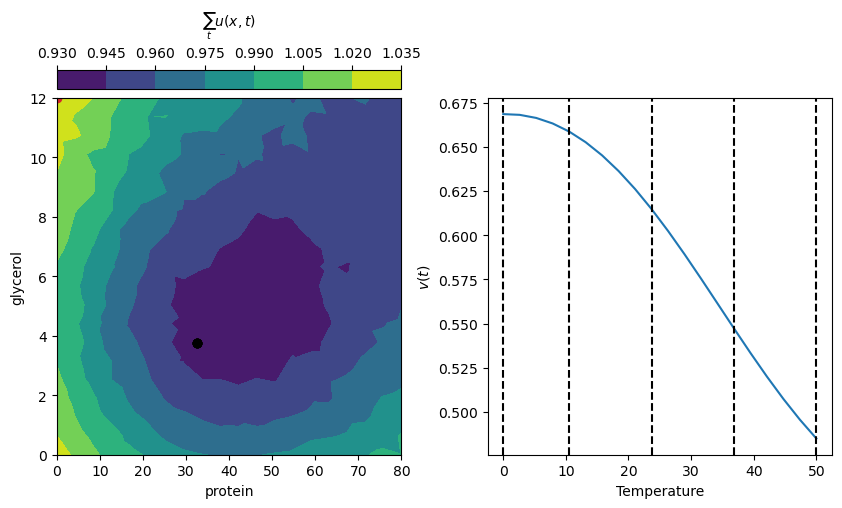

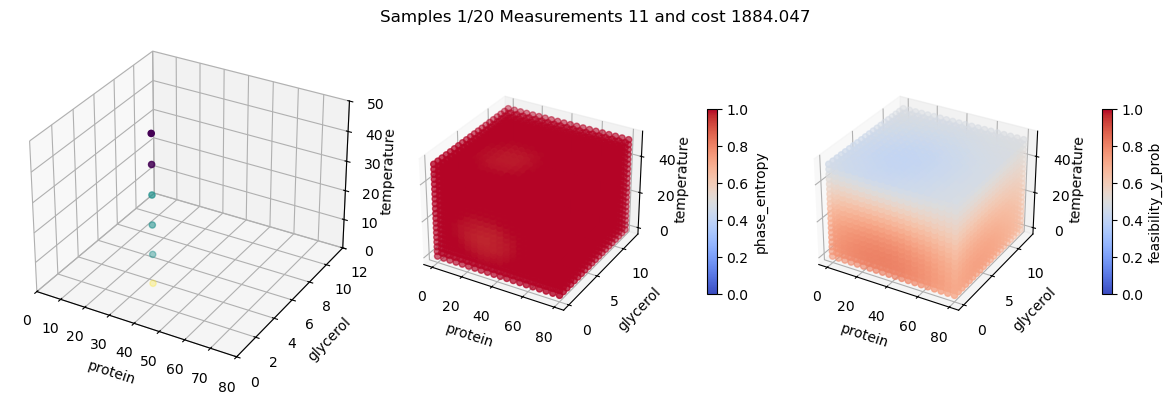

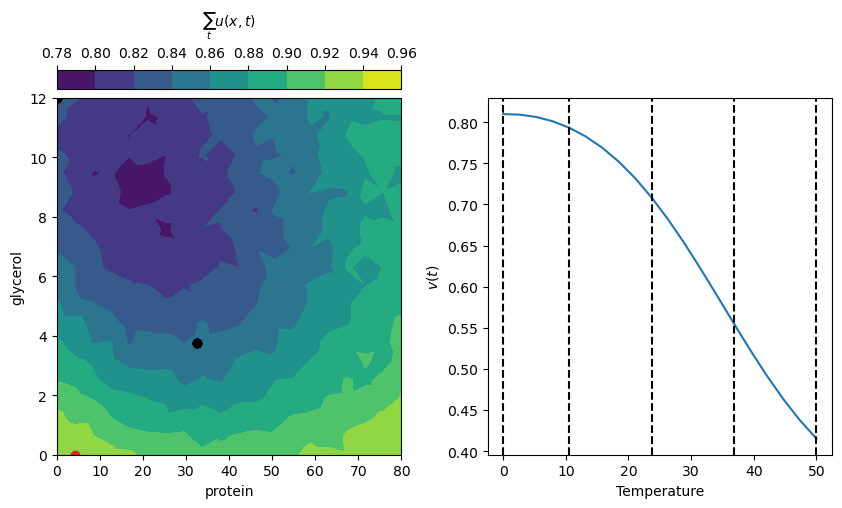

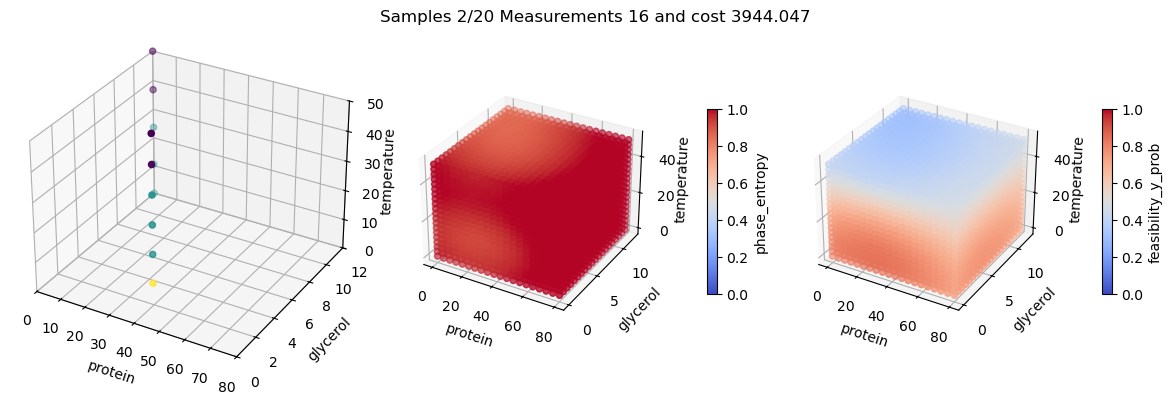

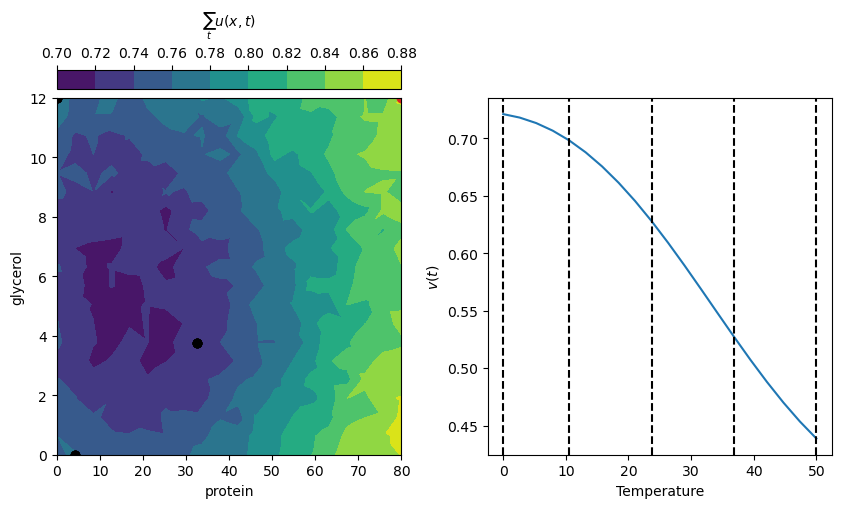

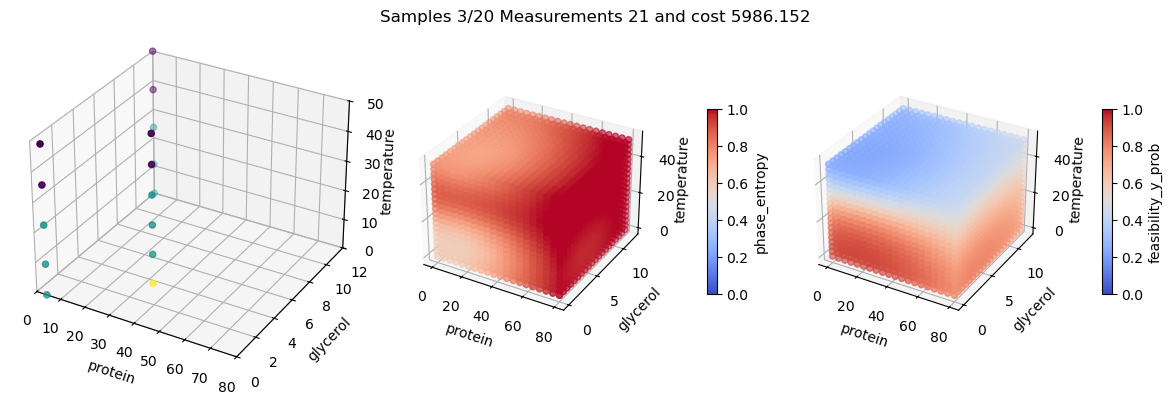

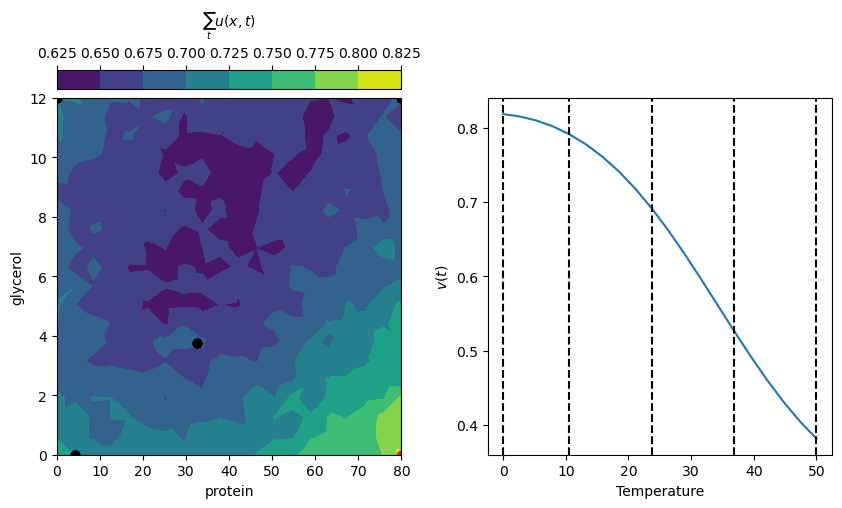

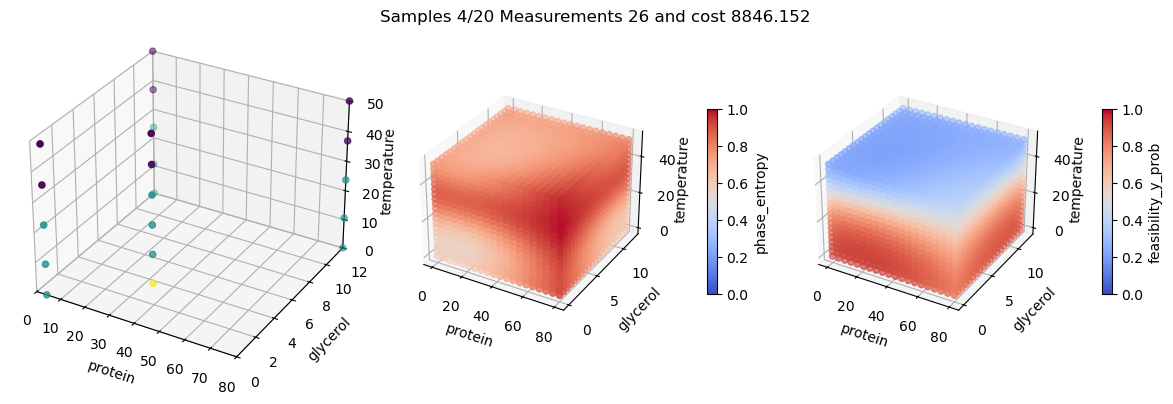

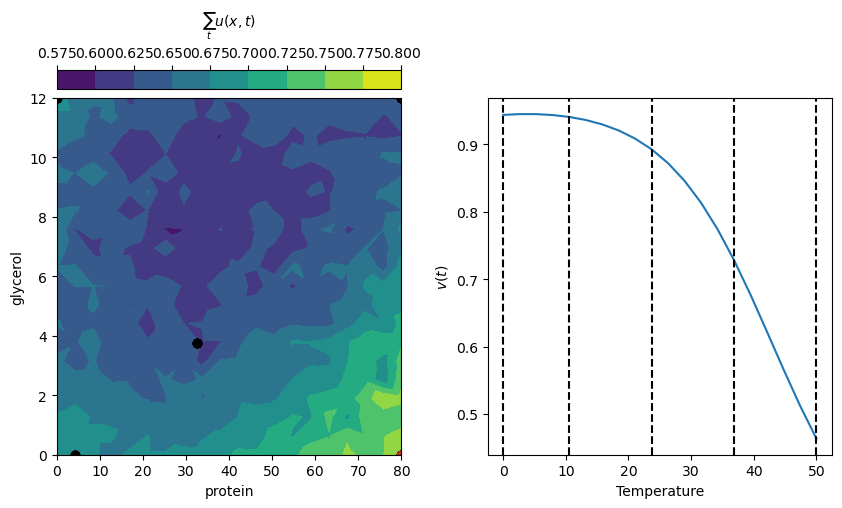

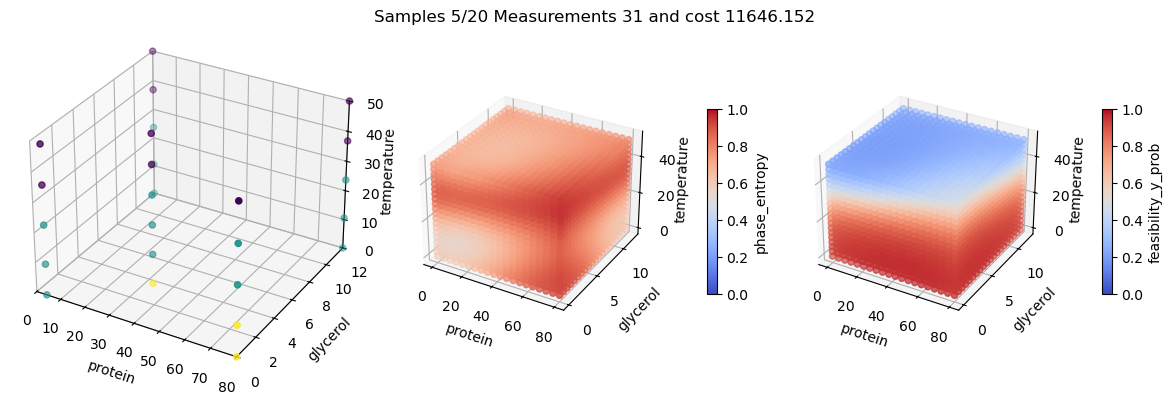

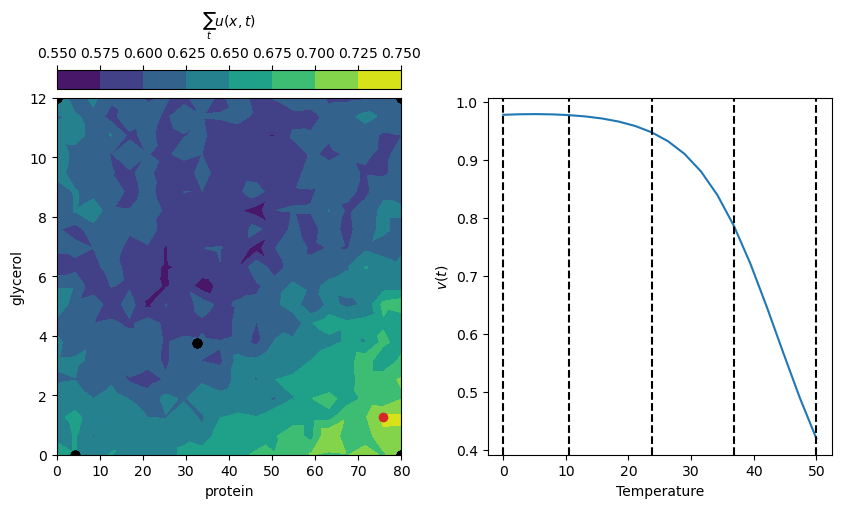

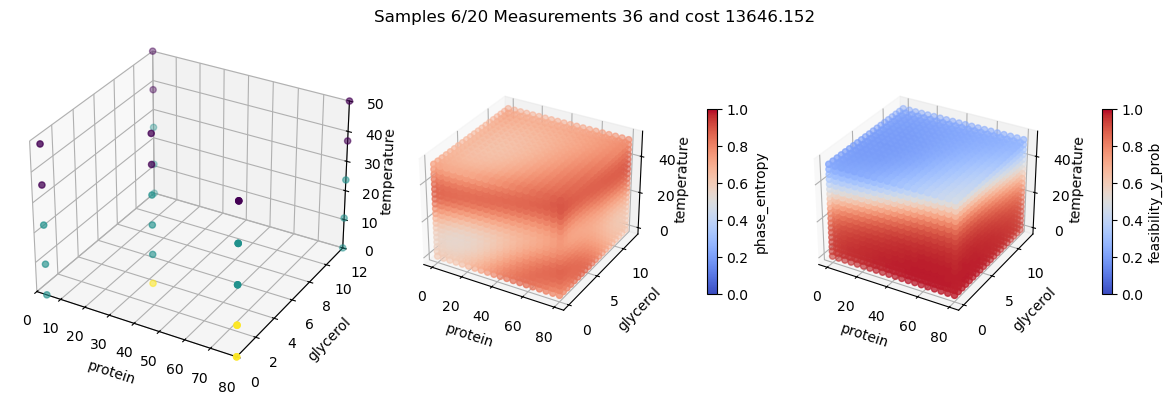

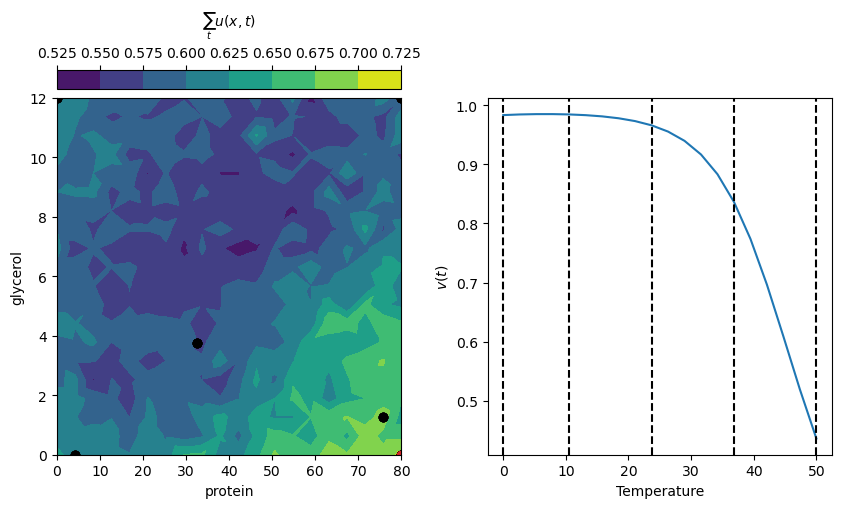

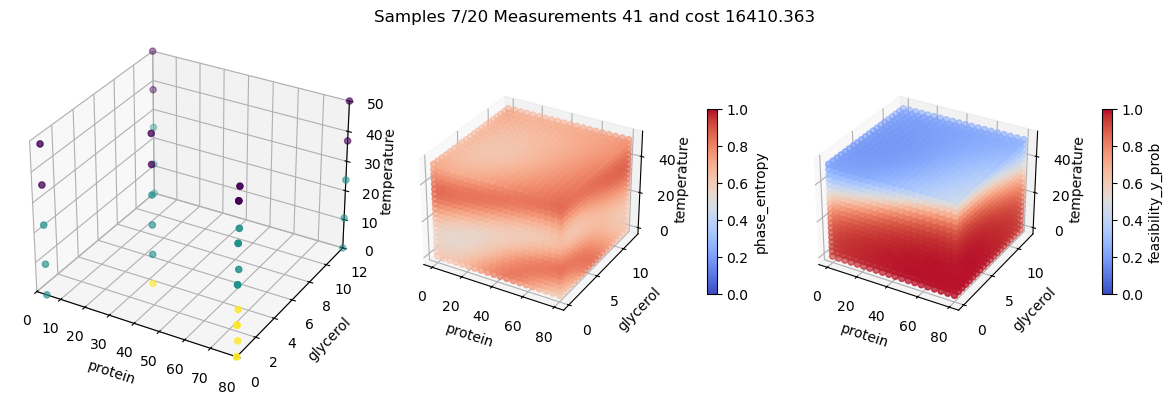

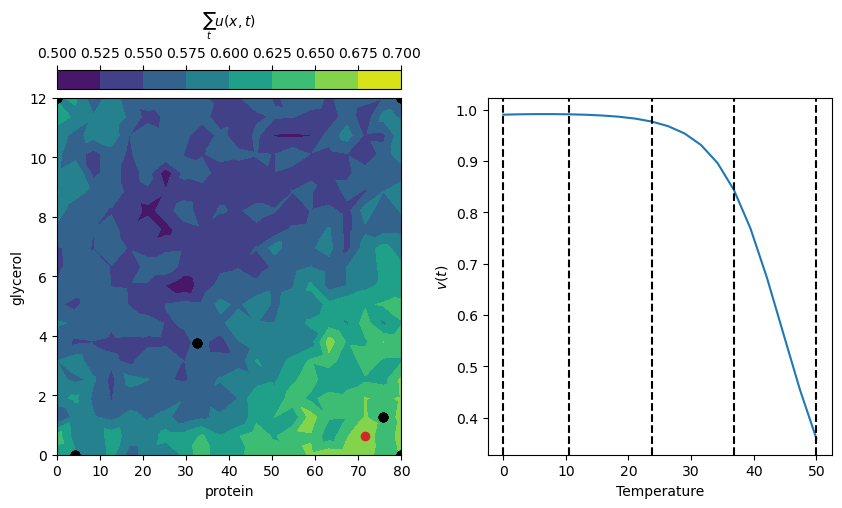

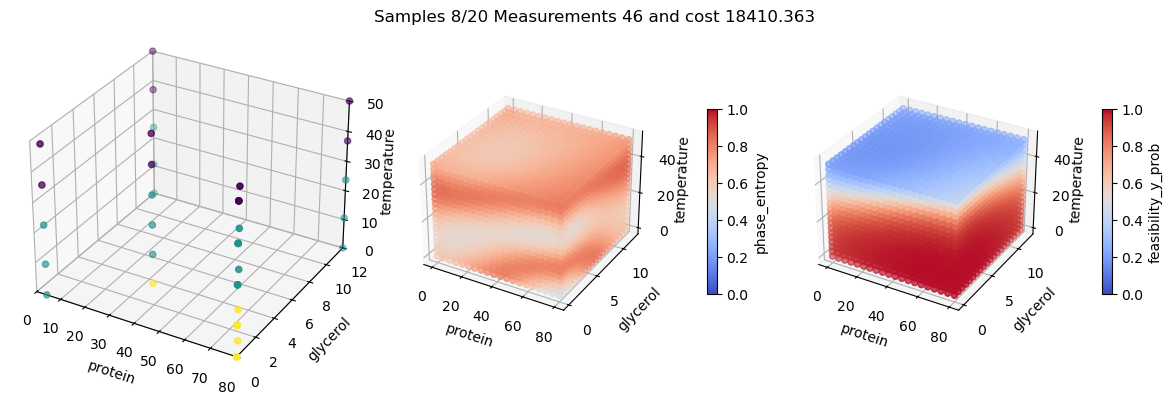

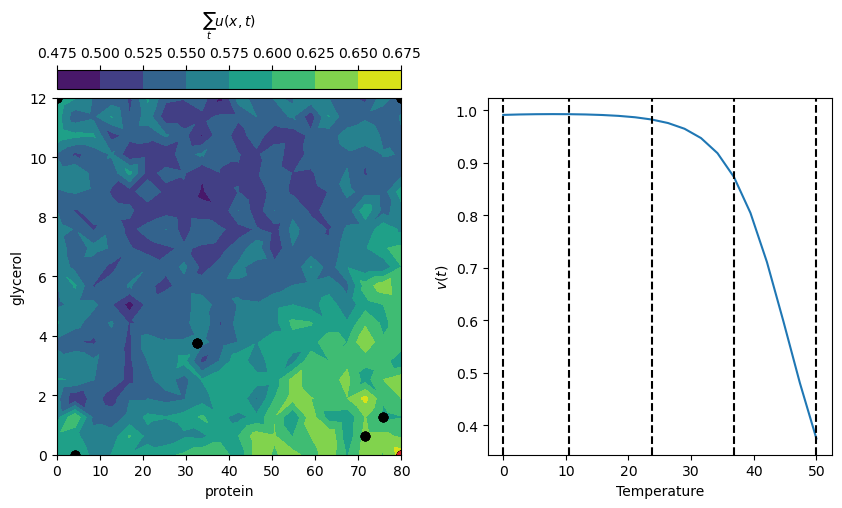

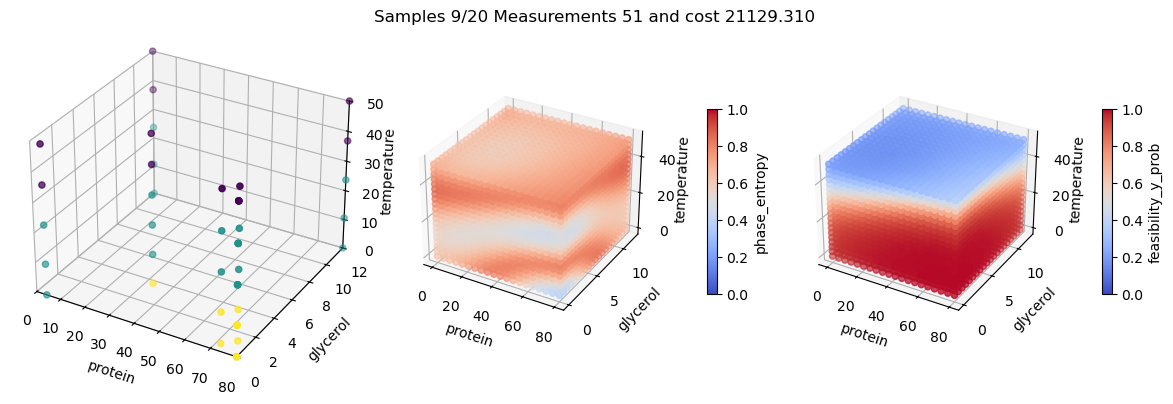

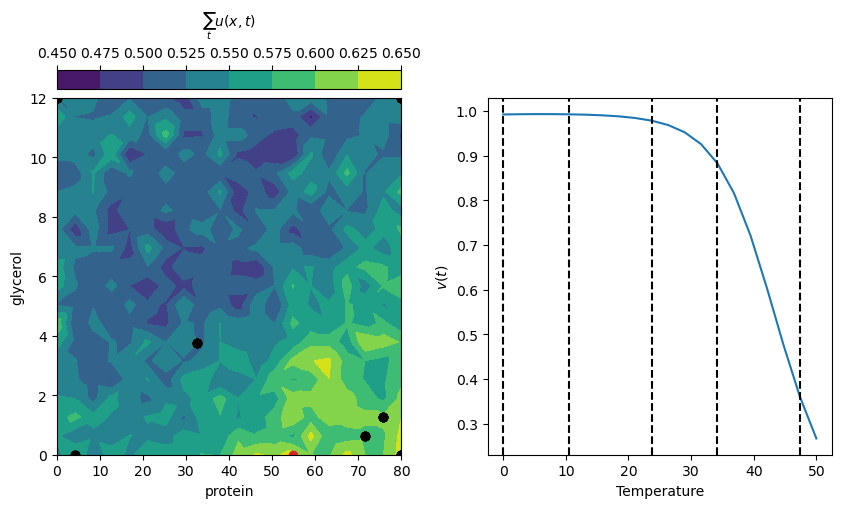

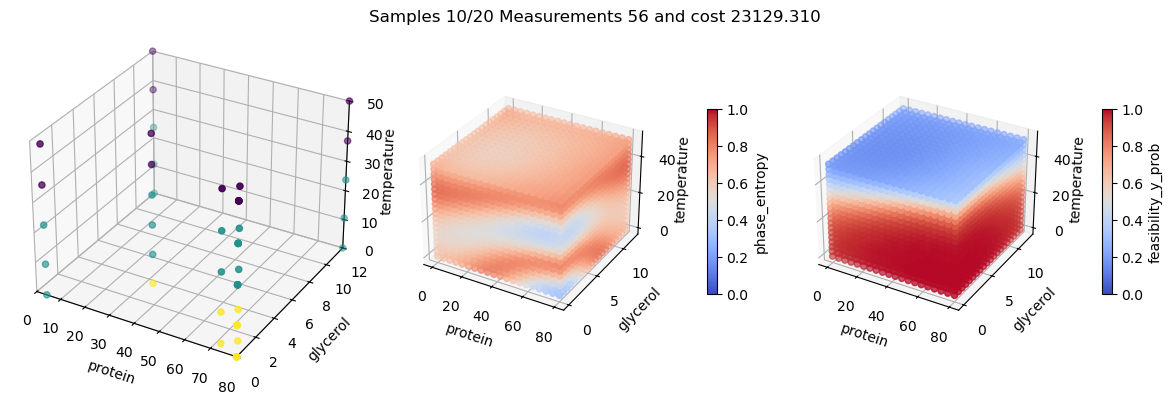

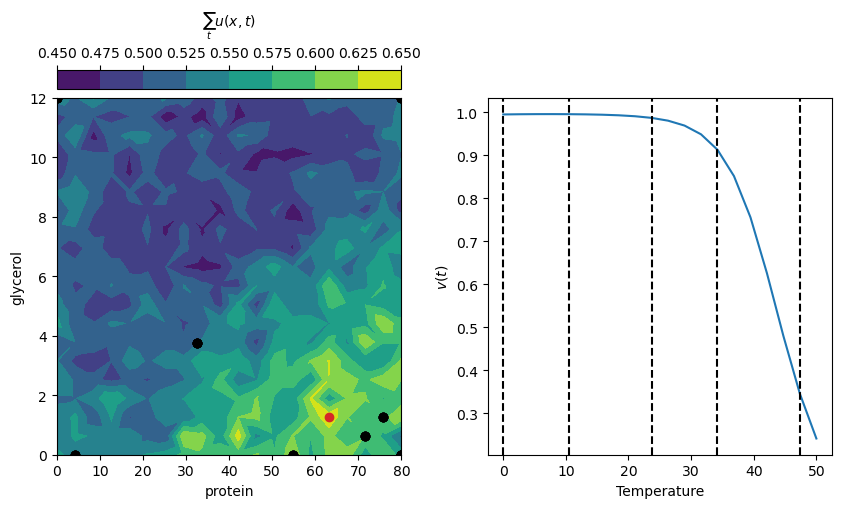

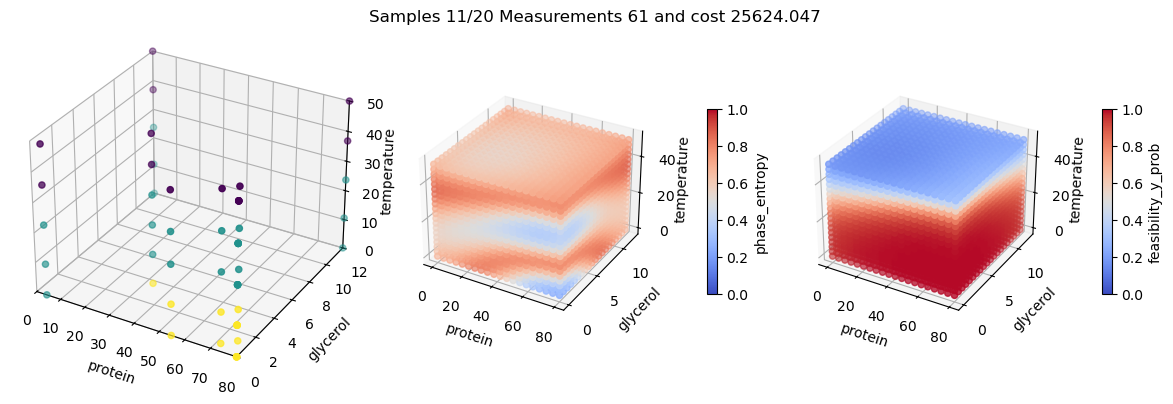

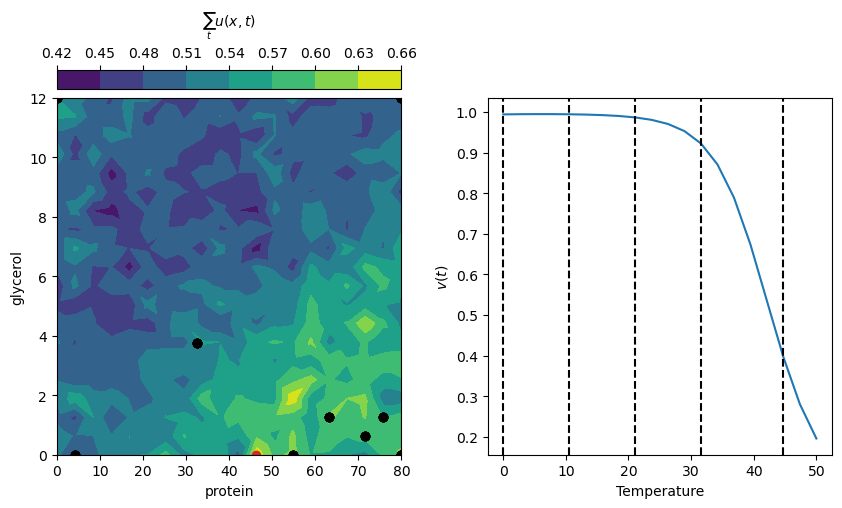

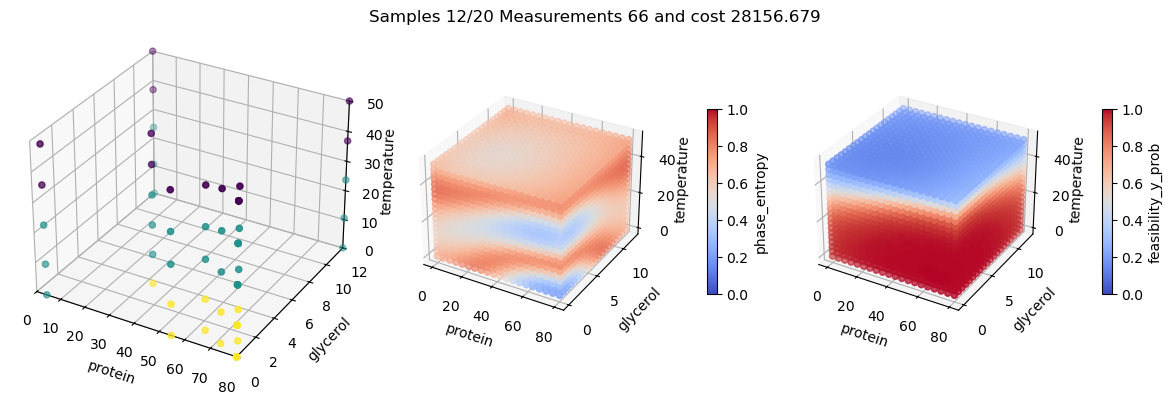

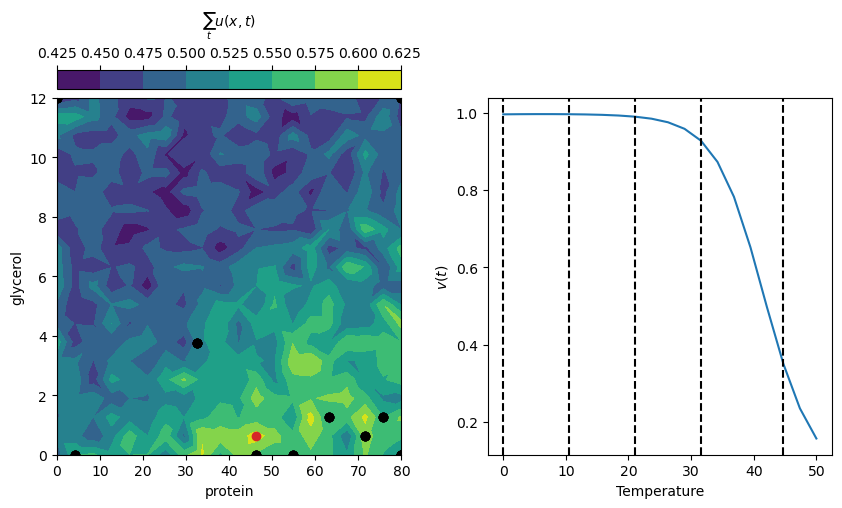

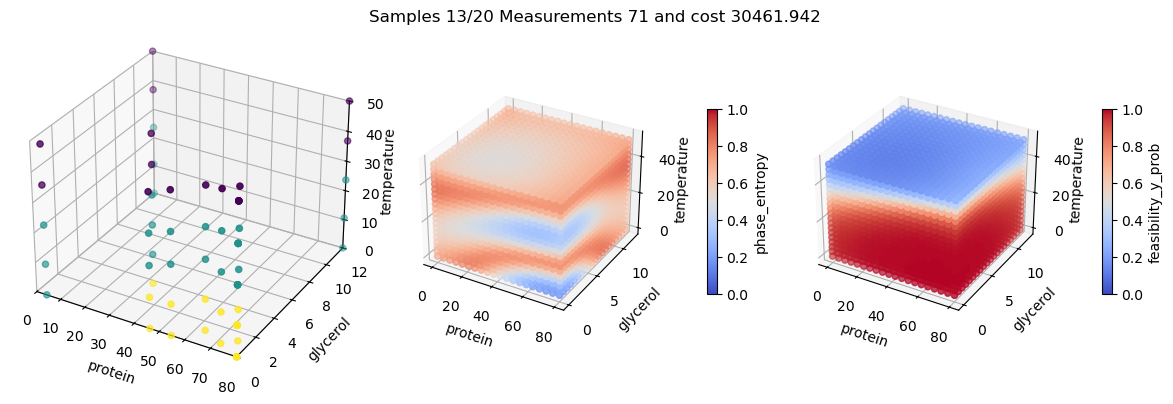

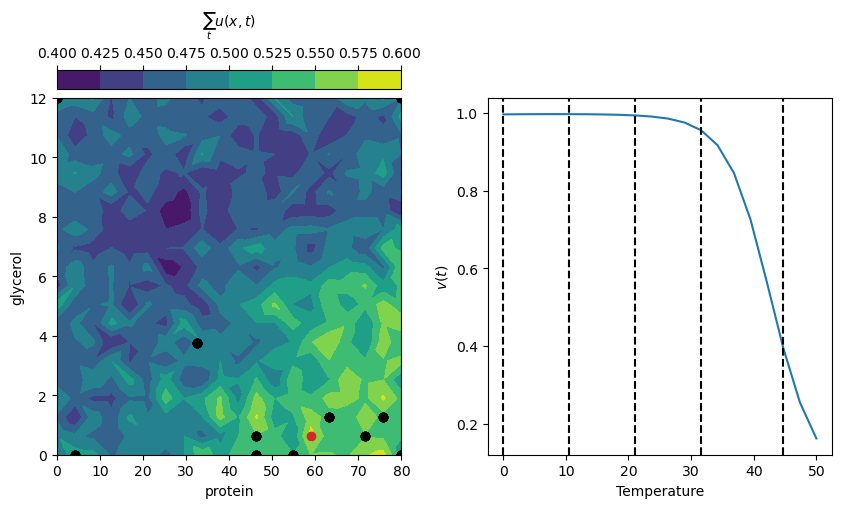

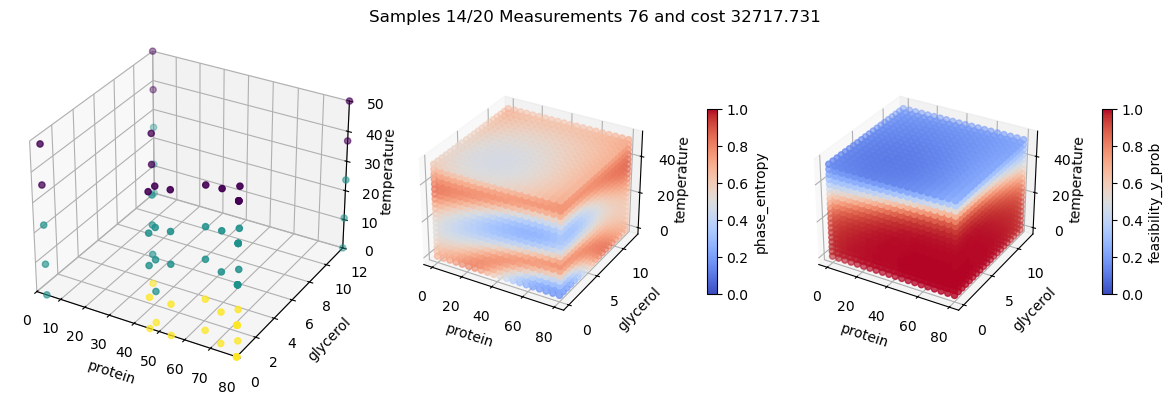

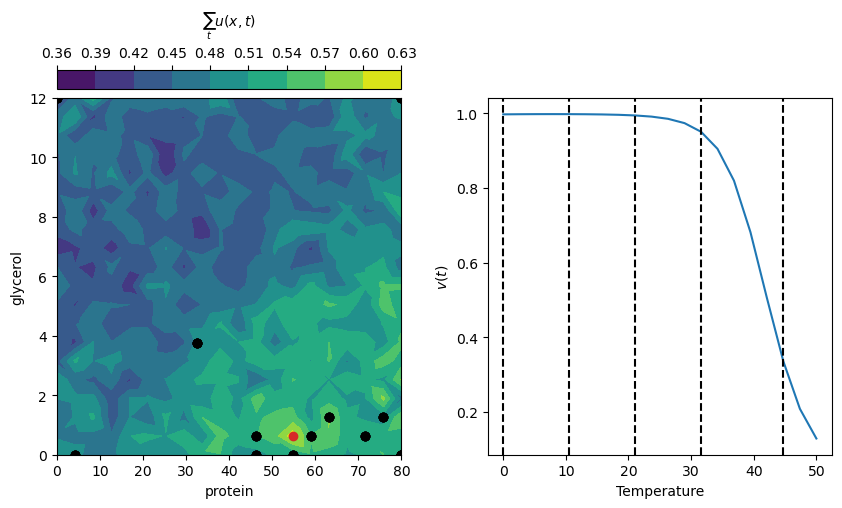

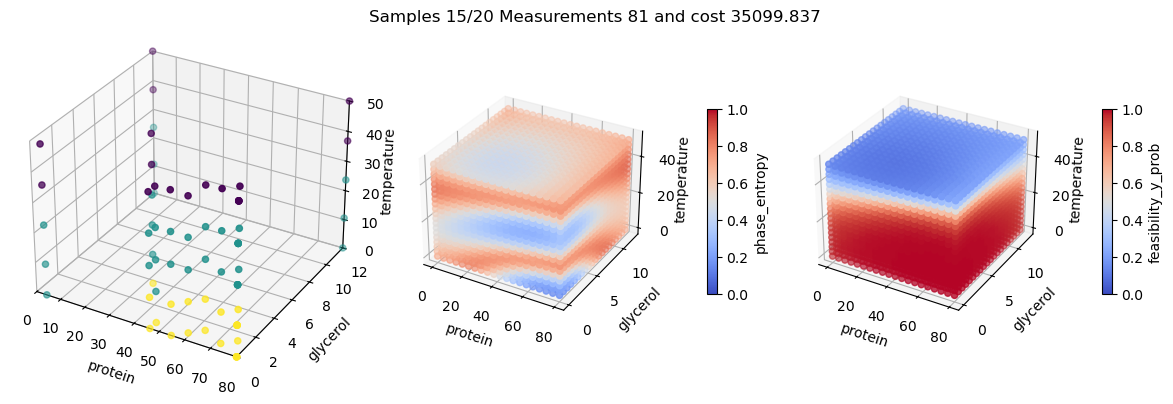

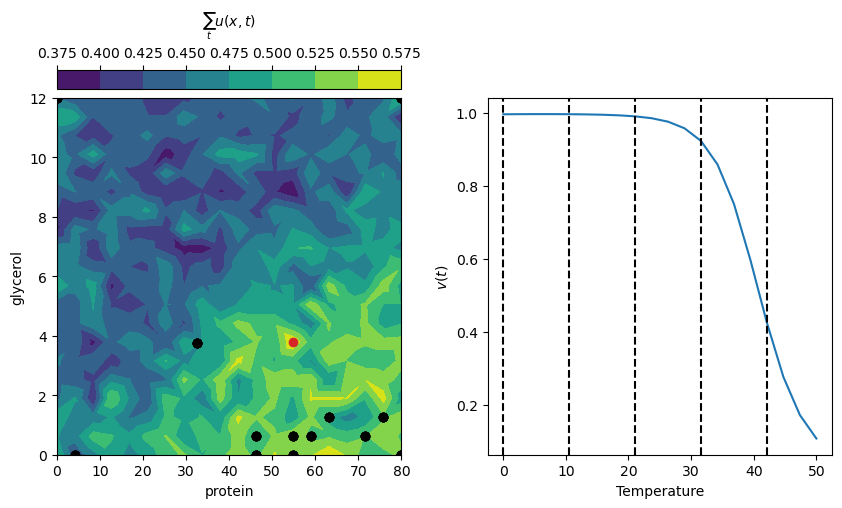

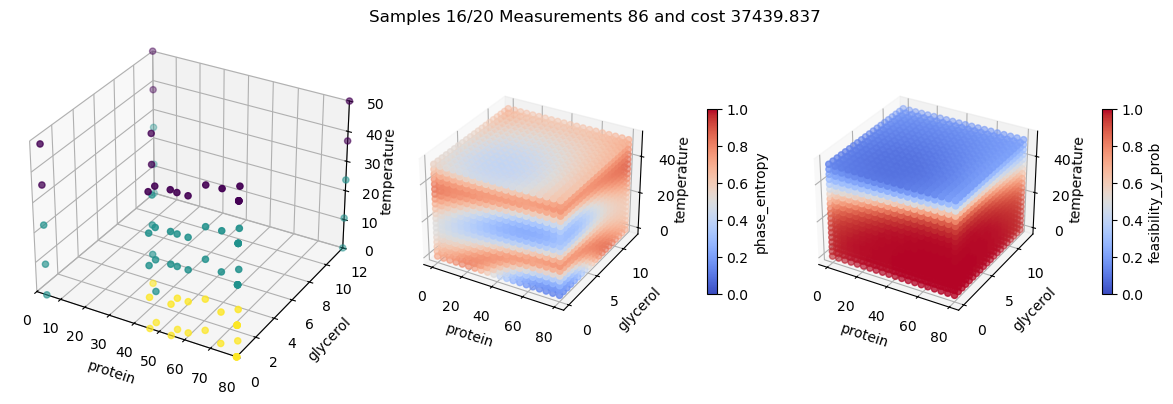

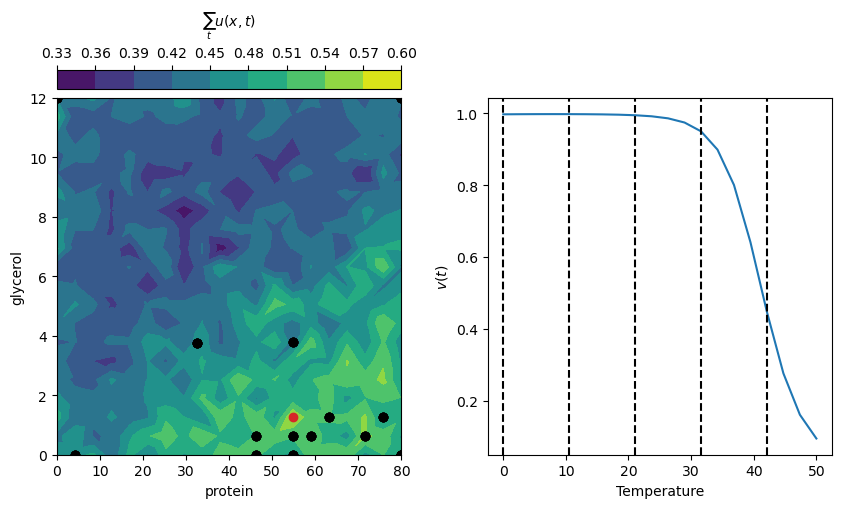

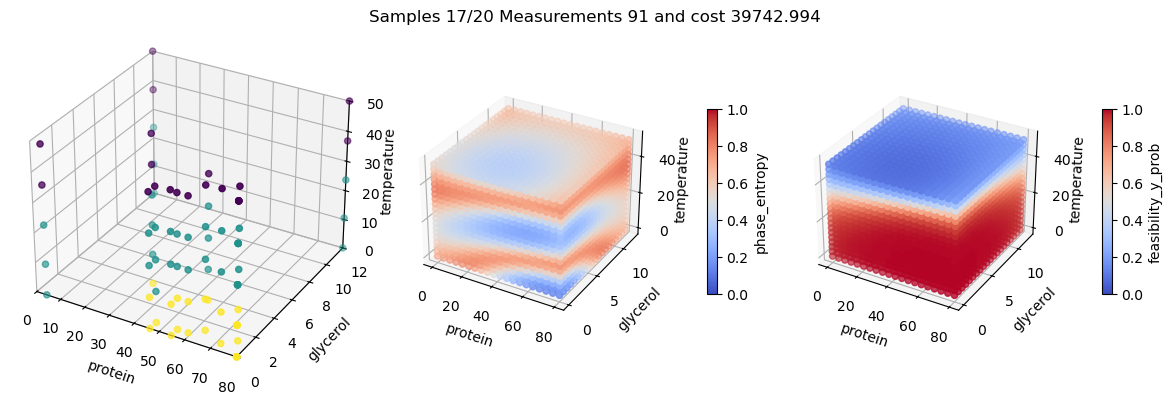

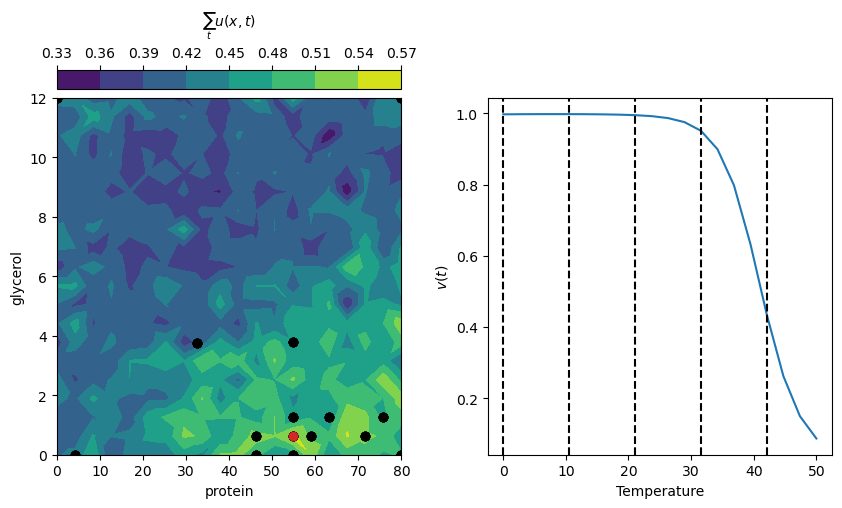

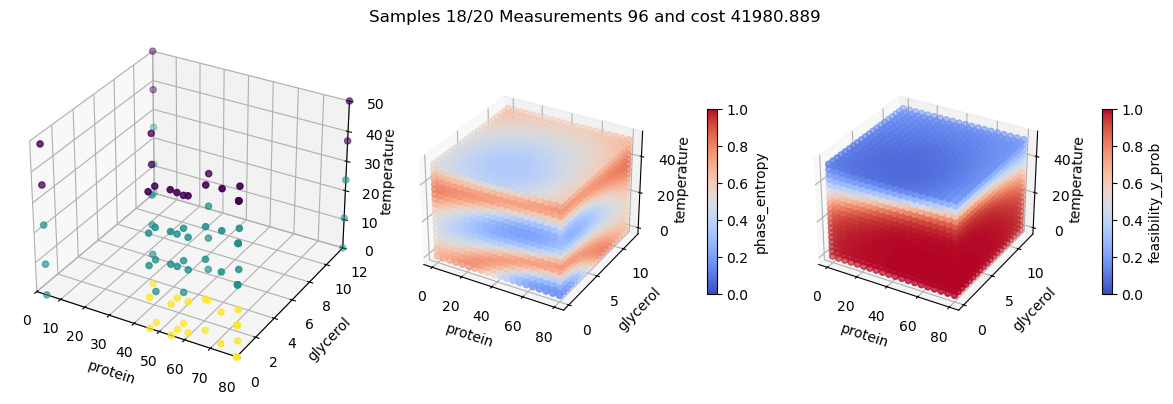

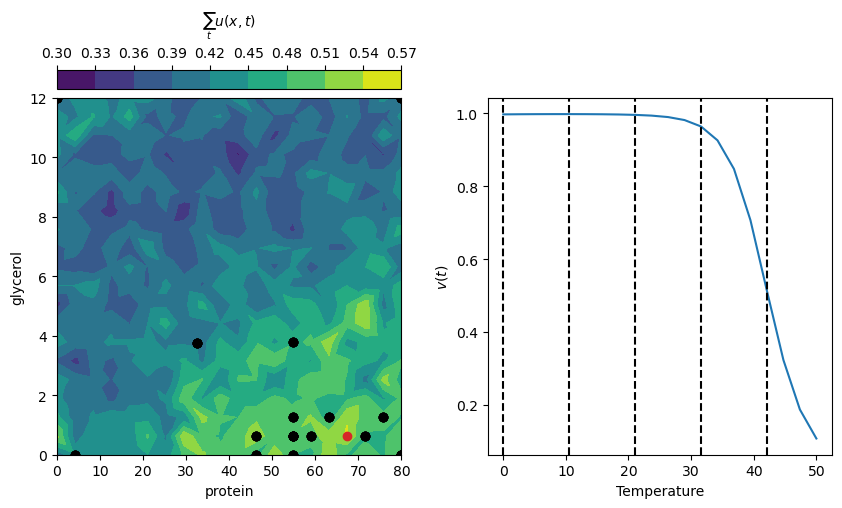

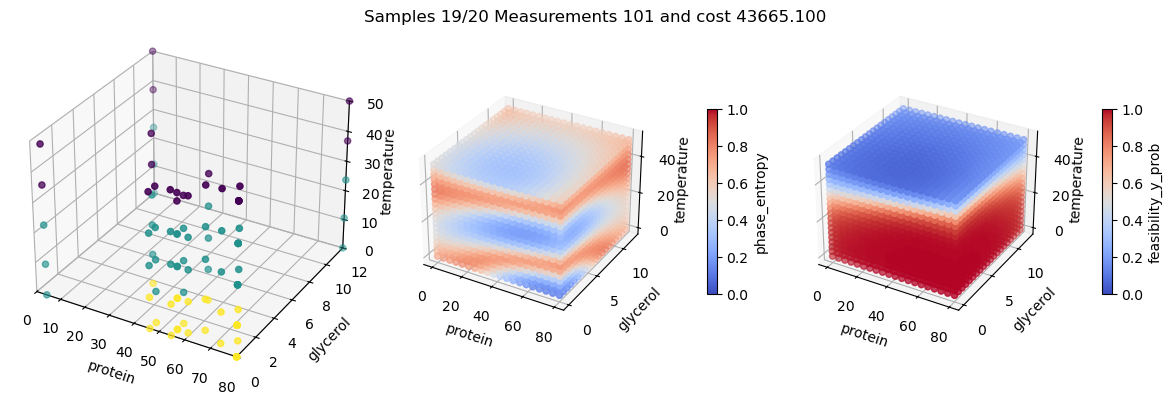

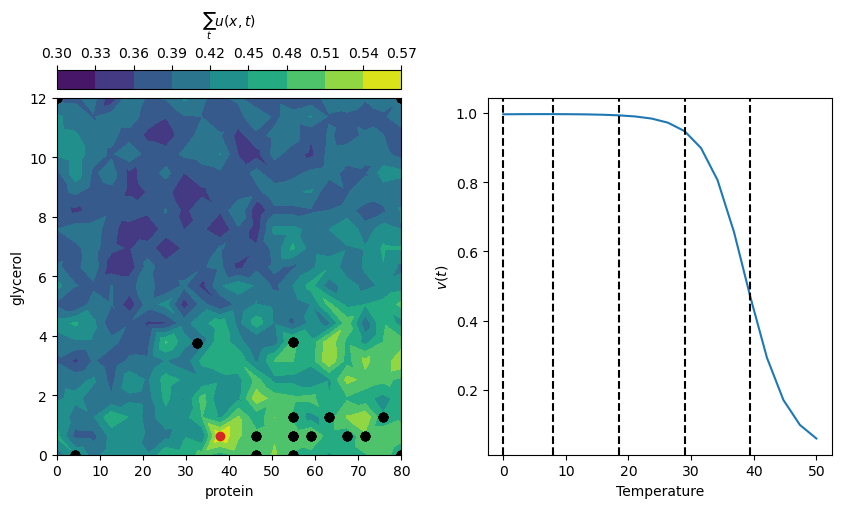

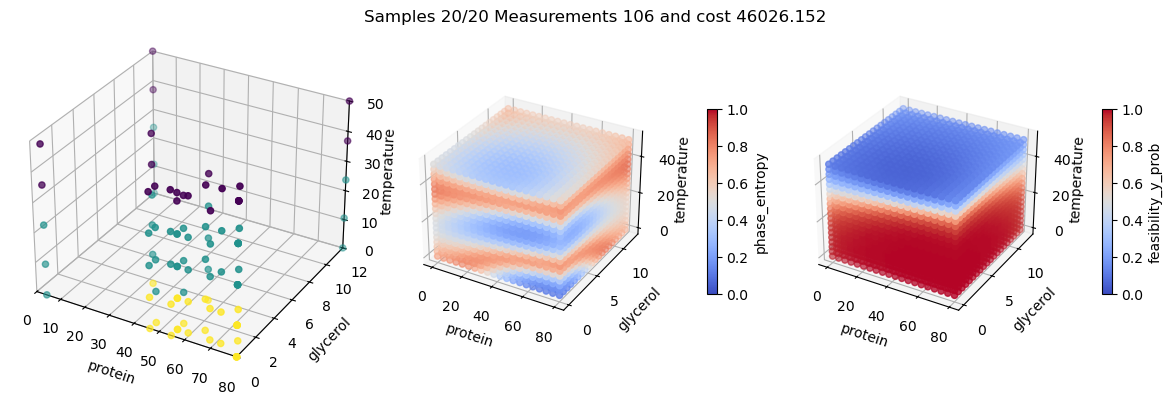

In [10]:
ds_running = ds_init.copy() 
num_samples = 20

for step in range(num_samples):
    ds_result = p.calculate(ds_running, disable_progress_bar=True)
    ds_new = []
    for t in ds_result.temperature_next.values:
        sample = {"protein": ds_result.composition_next.sel({"protein_glycerol_d":"protein"}).values.item(),
                "glycerol" : ds_result.composition_next.sel({"protein_glycerol_d":"glycerol"}).values.item(),
                "temperature" : t.item()
        }  
        ds = sim.simple_expose(sample)
        ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
        ds['phases'] = int(ds.attrs['labels'])
        ds_new.append(ds)

    ds_new = xr.concat(ds_new, dim='sample')
    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    
    out = expense.calculate(ds_result)

    plot_sampling(ds_result,
                  "design_space",
                  "ds_dim",
                  "_".join(i for i in ['protein', 'glycerol'])+"_domain",
                  "composition_utility_with_cost",
                  "composition_next",
                  "temperature_domain",
                  "temperature_utility",
                  "temperature_next"
                  )
    plt.show()

    fig, axs = plot_progress(ds_result, 
                "design_space", 
                "design_space_grid", 
                "ds_dim", 
                ['protein', 'glycerol'],
                "temperature",
                "phases",
                "phase_entropy",
                "feasibility_y_prob"
            )
    fig.suptitle(f"Samples {step+1}/{num_samples} Measurements {len(ds_running.sample)} " + 
                f"and cost {out.output['expense'].values.item():.3f}")
    plt.show()

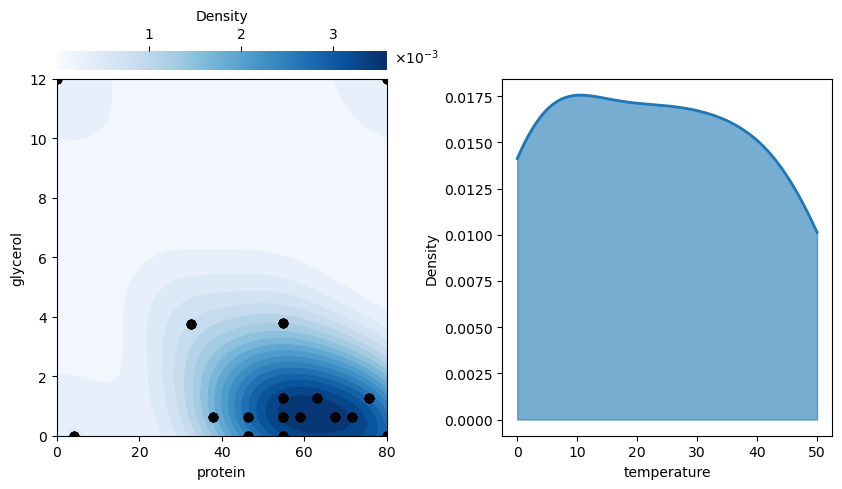

In [11]:
plot_sampling_densities(ds_running)
plt.show()